## Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Libraries

In [ ]:
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

## Loading the Dataset

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/House Prices Predictor/house_prices.csv')

# 1. Drop columns that are 100% missing
df = df.drop(columns=['Dimensions', 'Plot Area'], errors='ignore')

# 2. Drop rows where the target price is missing
df = df.dropna(subset=['Price (in rupees)'])

# 3. Clean Area columns (convert strings like '1200 sqft' to float)
def clean_area(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        res = ''.join(filter(lambda x: x.isdigit() or x == '.', value))
        try:
            return float(res) if res else np.nan
        except:
            return np.nan
    return float(value)

df['Carpet Area'] = df['Carpet Area'].apply(clean_area)
df['Super Area'] = df['Super Area'].apply(clean_area)

print(f"Dataset shape after cleaning: {df.shape}")
display(df.head())
df.info()

Dataset shape after cleaning: (169866, 19)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500.0,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473.0,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779.0,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635.0,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN
5,5,1 BHK Ready to Occupy Flat for sale in Virat A...,Creatively planned and constructed is a 1 BHK ...,45 Lac,6618.0,thane,NaN,Ready to Move,2 out of 7,Resale,Unfurnished,East,"Garden/Park, Main Road",Virat Aangan,1,1,NaN,Co-operative Society,680.0


<class 'pandas.core.frame.DataFrame'>
Index: 169866 entries, 0 to 187530
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              169866 non-null  int64  
 1   Title              169866 non-null  object 
 2   Description        166983 non-null  object 
 3   Amount(in rupees)  169866 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           169866 non-null  object 
 6   Carpet Area        93631 non-null   float64
 7   Status             169271 non-null  object 
 8   Floor              163023 non-null  object 
 9   Transaction        169860 non-null  object 
 10  Furnishing         167806 non-null  object 
 11  facing             107814 non-null  object 
 12  overlooking        99220 non-null   object 
 13  Society            72433 non-null   object 
 14  Bathroom           169112 non-null  object 
 15  Balcony            124804 non-null  object 
 16  Car Par

## Explore Data

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

print("Training set shape:", train.shape)
print("Test set shape:", test.shape)
print("\nFirst few rows:")
display(train.head())

Training set shape: (135892, 19)
Test set shape: (33974, 19)

First few rows:


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area
158607,158607,3 BHK Ready to Occupy Flat for sale in Exotica...,This ready to move-in 3 BHK flat is available ...,64 Lac,3798.0,ghaziabad,1685.0,Ready to Move,12 out of 19,Resale,Semi-Furnished,North - East,"Garden/Park, Pool, Main Road",Exotica Eastern Court,3,3,1 Covered,Freehold,NaN
97430,97430,3 BHK Ready to Occupy Flat for sale Girish Par...,"Near Girish Park Metro, near bazar, near main ...",40 Lac,3200.0,kolkata,950.0,Ready to Move,3 out of 3,Resale,Semi-Furnished,South - East,NaN,NaN,2,1,NaN,Freehold,NaN
139461,139461,3 BHK Ready to Occupy Flat for sale Shiv Nagar...,This gorgeous 3 BHK Flat is available for sale...,1.35 Cr,11278.0,new-delhi,133.0,Ready to Move,1 out of 3,New Property,Unfurnished,East,"Garden/Park, Main Road",NaN,3,2,NaN,Freehold,NaN
121969,121969,3 BHK Ready to Occupy Flat for sale in Harmony...,"Dwarka Sector 23, New Delhi has an appealing 3...",2.35 Cr,10930.0,new-delhi,1760.0,Ready to Move,6 out of 8,Resale,Semi-Furnished,North - East,"Garden/Park, Main Road",Harmony Apartment,4,3,"1 Covered,",Freehold,NaN
44147,44147,3 BHK Ready to Occupy Flat for sale in Dugar S...,Have a look at this immaculate 3 BHK flat for ...,80 Lac,5060.0,chennai,NaN,Ready to Move,2 out of 4,Resale,Semi-Furnished,NaN,NaN,NaN,3,NaN,NaN,NaN,1581.0


## Target Variable Analysis & Log Transformation Justification

Target Variable Statistics:
count    1.698660e+05
mean     7.583772e+03
std      2.724171e+04
min      0.000000e+00
25%      4.297000e+03
50%      6.034000e+03
75%      9.450000e+03
max      6.700000e+06
Name: Price (in rupees), dtype: float64


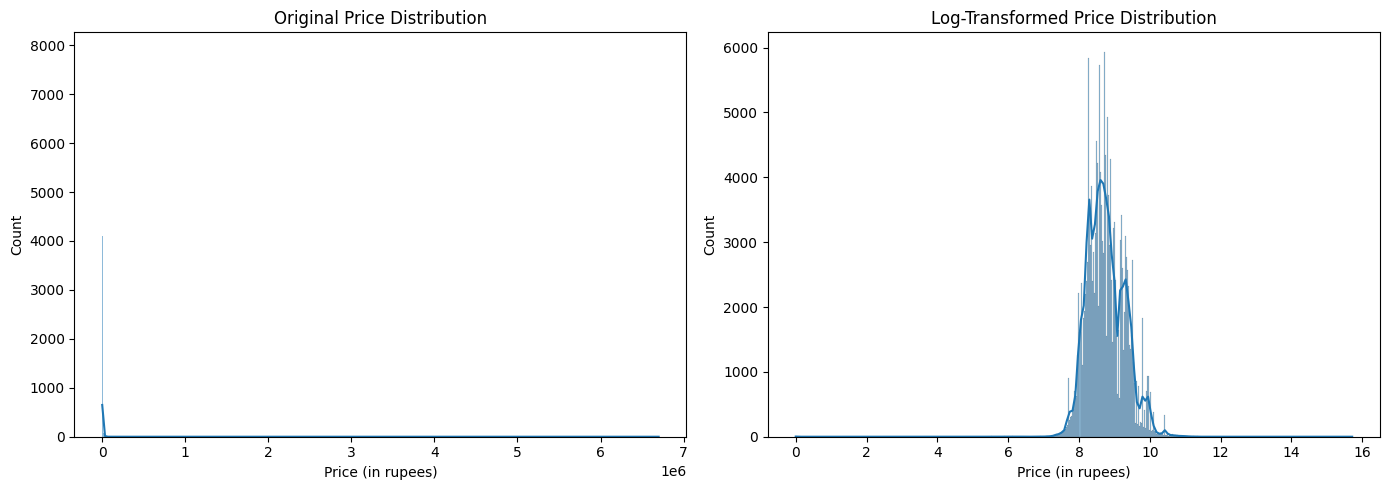


Original Skewness: 177.11
Log-Transformed Skewness: 0.05


In [ ]:
# Analyze the target variable
print("Target Variable Statistics:")
print(df['Price (in rupees)'].describe())

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Price (in rupees)'], kde=True, ax=axes[0])
axes[0].set_title('Original Price Distribution')

sns.histplot(np.log1p(df['Price (in rupees)']), kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Price Distribution')

plt.tight_layout()
plt.show()

from scipy.stats import skew
print(f"\nOriginal Skewness: {skew(df['Price (in rupees)'].dropna()):.2f}")
print(f"Log-Transformed Skewness: {skew(np.log1p(df['Price (in rupees)'].dropna())):.2f}")

## Missing Value Analysis

In [ ]:
# Missing values analysis
def missing_analysis(df):
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    missing_table = pd.DataFrame({
        'Missing_Count': missing,
        'Percentage': missing_pct
    })
    missing_table = missing_table[missing_table['Missing_Count'] > 0].sort_values(
        'Percentage', ascending=False
    )
    return missing_table

print("Missing Values in Training Data:")
print(missing_analysis(train))

Missing Values in Training Data:
             Missing_Count  Percentage
Society              78044   57.430901
Super Area           74849   55.079769
Car Parking          72938   53.673505
Carpet Area          61043   44.920231
overlooking          56580   41.636005
facing               49636   36.526065
Ownership            46610   34.299297
Balcony              36062   26.537250
Floor                 5487    4.037765
Description           2284    1.680746
Furnishing            1634    1.202425
Bathroom               599    0.440791
Status                 495    0.364260
Transaction              5    0.003679


##

## Identifying Numerical and Categorical Features

In [ ]:
# Identify feature types
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features = [f for f in numerical_features if f not in ['Price (in rupees)', 'Index']]

# Exclude high-cardinality text columns from basic categorical processing
all_categorical = df.select_dtypes(include=['object']).columns.tolist()
high_cardinality = ['Title', 'Description', 'location', 'Society']
categorical_features = [f for f in all_categorical if f not in high_cardinality]

print(f"Numerical features: {numerical_features}")
print(f"Categorical features (to be encoded): {categorical_features}")
print(f"High cardinality features (excluded for now): {high_cardinality}")

Numerical features: ['Carpet Area', 'Super Area']
Categorical features (to be encoded): ['Amount(in rupees)', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership']
High cardinality features (excluded for now): ['Title', 'Description', 'location', 'Society']


## Correlation Analysis Between Numerical Features and SalesPrice


Top 10 Correlated Features:
Price (in rupees)    1.000000
Carpet Area          0.019215
Super Area           0.009852
Name: Price (in rupees), dtype: float64


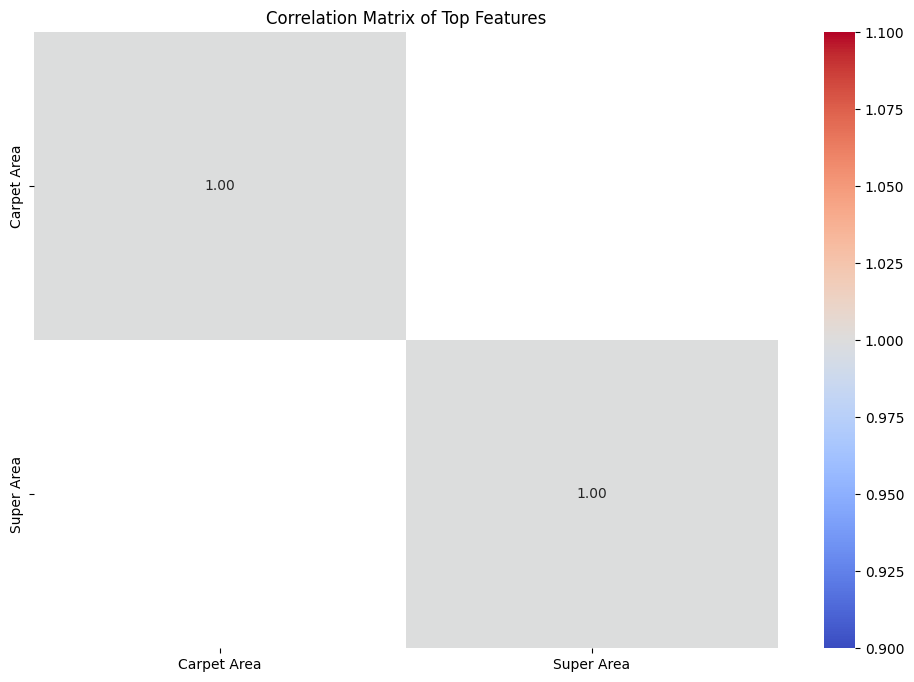

In [ ]:
# Correlation with target
correlations = train[numerical_features + ['Price (in rupees)']].corr()['Price (in rupees)'].sort_values(ascending=False)
print("\nTop 10 Correlated Features:")
print(correlations.head(11))  # Top 10 + Price (in rupees) itself

# Visualize top correlations
top_features = correlations.head(11).index[1:]  # Exclude Price (in rupees) itself
plt.figure(figsize=(12, 8))
sns.heatmap(train[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Top Features')
plt.show()

## Preparing Training and Test Data for Modeling

In [ ]:
# Save test IDs for later
test_ids = test['Index']

# Create X and y
X = train.drop(['Index', 'Price (in rupees)'], axis=1)
y = np.log1p(train['Price (in rupees)'])  # Log transform target

# Prepare test set
X_test = test.drop(['Index'], axis=1)

## Defining Missing Value Imputation Strategies

In [ ]:
# Numerical features: fill with median (robust to outliers)
# Categorical features: fill with 'None' or most frequent

from sklearn.impute import SimpleImputer

# For training data
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value='None')

## Derived Features from Existing House Attributes

In [ ]:
def safe_auto_feature_engineering(df, is_test=False, target_col='Price (in rupees)'):
    """
    Safe feature engineering that prevents data leakage
    """
    df = df.copy()

    # Get numeric columns, excluding the target variable
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)

    # INTERACTION FEATURES
    if len(numeric_cols) >= 2:
        col1, col2 = numeric_cols[0], numeric_cols[1]
        df[f'{col1}_x_{col2}'] = df[col1] * df[col2]

        if len(numeric_cols) >= 3:
            col3 = numeric_cols[2]
            df[f'{col1}_x_{col3}'] = df[col1] * df[col3]

    # POLYNOMIAL FEATURES (Squared)
    area_cols = [col for col in numeric_cols if any(keyword in col.lower()
                  for keyword in ['area', 'size', 'dimension', 'sq', 'sqft'])]
    for col in area_cols[:3]:  # Limit to 3 to avoid too many features
        df[f'{col}_squared'] = df[col] ** 2

    # BINARY INDICATORS (Has feature?)
    for col in numeric_cols[:5]:  # First 5 numeric columns
        if (df[col] == 0).sum() > 0:
            zero_pct = 100 * (df[col] == 0).sum() / len(df)
            if zero_pct > 5:  # Only if at least 5% are zeros
                df[f'Has_{col}'] = (df[col] > 0).astype(int)

    # RATIO FEATURES (if applicable)
    if 'Plot Area' in numeric_cols and 'Dimensions' in numeric_cols:
        df['Area_to_Dimension_Ratio'] = df['Plot Area'] / (df['Dimensions'] + 1)

    return df


# Apply to TRAIN and TEST
X_train_engineered = safe_auto_feature_engineering(X, is_test=False, target_col='Price (in rupees)')
X_test_engineered = safe_auto_feature_engineering(X_test, is_test=True, target_col='Price (in rupees)')


## Handle Skewed Features

In [ ]:
from scipy.stats import skew

# Update X and X_test with engineered features
X = X_train_engineered.copy()
X_test = X_test_engineered.copy()

# Get updated numerical features list (after feature engineering)
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Analyzing skewness for {len(numerical_features)} numerical features...\n")

# Calculate skewness for each feature
skewness = X[numerical_features].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

print("Top 10 Most Skewed Features:")
print(skewness.head(10))
print("\n" + "="*50)

# Identify highly skewed features (threshold: |skewness| > 0.5)
high_skew = skewness[abs(skewness) > 0.5]

print(f"\nFeatures with high skewness (>{0.5}): {len(high_skew)}")
print(high_skew)

# Apply log transformation to highly skewed features
print("\n" + "="*50)
print("Applying log transformation to skewed features...\n")

for feat in high_skew.index:
    # Log transform (adding 1 to handle zeros)
    X[feat] = np.log1p(X[feat])
    X_test[feat] = np.log1p(X_test[feat])
    print(f"✓ Transformed: {feat} (original skewness: {skewness[feat]:.2f})")

Analyzing skewness for 5 numerical features...

Top 10 Most Skewed Features:
Super Area_squared          247.042975
Carpet Area_squared         234.721188
Super Area                  208.935728
Carpet Area                 140.402037
Carpet Area_x_Super Area           NaN
dtype: float64


Features with high skewness (>0.5): 4
Super Area_squared     247.042975
Carpet Area_squared    234.721188
Super Area             208.935728
Carpet Area            140.402037
dtype: float64

Applying log transformation to skewed features...

✓ Transformed: Super Area_squared (original skewness: 247.04)
✓ Transformed: Carpet Area_squared (original skewness: 234.72)
✓ Transformed: Super Area (original skewness: 208.94)
✓ Transformed: Carpet Area (original skewness: 140.40)


## Create Train/Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% validation)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("="*50)
print("DATA SPLIT SUMMARY")
print("="*50)
print(f"Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_valid.shape[0]:,} samples ({X_valid.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples")
print(f"\nNumber of features: {X_train.shape[1]}")
print("✓ Data split complete!")

DATA SPLIT SUMMARY
Training set:   108,713 samples (80.0%)
Validation set: 27,179 samples (20.0%)
Test set:       33,974 samples

Number of features: 20
✓ Data split complete!


## Preprocessing Pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Update feature type lists after engineering
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("="*50)
print("PREPROCESSING PIPELINE")
print("="*50)
print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features)
    ],
    remainder='passthrough'
)

print("\n✓ Preprocessing pipeline created!")
print("  - Numerical: StandardScaler (mean=0, std=1)")
print("  - Categorical: OneHotEncoder (handles unknown values)")

PREPROCESSING PIPELINE
Numerical features: 5
Categorical features: 15

✓ Preprocessing pipeline created!
  - Numerical: StandardScaler (mean=0, std=1)
  - Categorical: OneHotEncoder (handles unknown values)


## Train Multiple Models & Compare

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import re


#  Encode high-cardinality features (memory-safe)


def encode_high_cardinality(X_train, X_valid, y_train):
    """
    Encode high-cardinality features using memory-efficient techniques.
    All encoding is learned from X_train only to prevent data leakage.
    """
    X_train = X_train.copy()
    X_valid = X_valid.copy()

    # --- TITLE: Extract BHK count and word count ---
    if 'Title' in X_train.columns:
        # Extract BHK number (e.g., "2 BHK" -> 2)
        X_train['title_bhk'] = X_train['Title'].astype(str).apply(
            lambda x: int(re.search(r'(\d+)\s*BHK', x).group(1)) if re.search(r'(\d+)\s*BHK', x) else 0
        )
        X_valid['title_bhk'] = X_valid['Title'].astype(str).apply(
            lambda x: int(re.search(r'(\d+)\s*BHK', x).group(1)) if re.search(r'(\d+)\s*BHK', x) else 0
        )
        # Word count as a proxy for listing detail
        X_train['title_word_count'] = X_train['Title'].astype(str).str.split().str.len()
        X_valid['title_word_count'] = X_valid['Title'].astype(str).str.split().str.len()
        X_train.drop(columns=['Title'], inplace=True)
        X_valid.drop(columns=['Title'], inplace=True)

    # --- DESCRIPTION: Word count and character count ---
    if 'Description' in X_train.columns:
        X_train['desc_word_count'] = X_train['Description'].astype(str).str.split().str.len()
        X_valid['desc_word_count'] = X_valid['Description'].astype(str).str.split().str.len()
        X_train['desc_char_count'] = X_train['Description'].astype(str).str.len()
        X_valid['desc_char_count'] = X_valid['Description'].astype(str).str.len()
        X_train.drop(columns=['Description'], inplace=True)
        X_valid.drop(columns=['Description'], inplace=True)

    # --- LOCATION: Target encoding (mean price per location) ---
    if 'location' in X_train.columns:
        # Learn mean target per location from TRAINING data only
        loc_target_mean = y_train.groupby(X_train['location']).mean()
        global_mean = y_train.mean()

        # Apply smoothing to avoid overfitting on rare locations
        loc_counts = X_train['location'].value_counts()
        smoothing_factor = 30  # minimum samples to trust the location mean
        loc_target_smoothed = (loc_counts * loc_target_mean + smoothing_factor * global_mean) / (loc_counts + smoothing_factor)

        X_train['location_target_enc'] = X_train['location'].map(loc_target_smoothed).fillna(global_mean)
        X_valid['location_target_enc'] = X_valid['location'].map(loc_target_smoothed).fillna(global_mean)

        # Frequency encoding (how common is this location?)
        loc_freq = X_train['location'].value_counts(normalize=True)
        X_train['location_freq'] = X_train['location'].map(loc_freq).fillna(0)
        X_valid['location_freq'] = X_valid['location'].map(loc_freq).fillna(0)

        X_train.drop(columns=['location'], inplace=True)
        X_valid.drop(columns=['location'], inplace=True)

    # --- SOCIETY: Target encoding + frequency encoding ---
    if 'Society' in X_train.columns:
        # Target encoding with smoothing
        soc_target_mean = y_train.groupby(X_train['Society']).mean()
        soc_counts = X_train['Society'].value_counts()
        smoothing_factor = 10
        soc_target_smoothed = (soc_counts * soc_target_mean + smoothing_factor * global_mean) / (soc_counts + smoothing_factor)

        X_train['society_target_enc'] = X_train['Society'].map(soc_target_smoothed).fillna(global_mean)
        X_valid['society_target_enc'] = X_valid['Society'].map(soc_target_smoothed).fillna(global_mean)

        # Frequency encoding
        soc_freq = X_train['Society'].value_counts(normalize=True)
        X_train['society_freq'] = X_train['Society'].map(soc_freq).fillna(0)
        X_valid['society_freq'] = X_valid['Society'].map(soc_freq).fillna(0)

        X_train.drop(columns=['Society'], inplace=True)
        X_valid.drop(columns=['Society'], inplace=True)

    return X_train, X_valid


# Apply encoding
X_train_enc, X_valid_enc = encode_high_cardinality(X_train, X_valid, y_train)

print(f"After encoding - Train shape: {X_train_enc.shape}, Valid shape: {X_valid_enc.shape}")
print(f"New features added from high-cardinality columns!")


# STEP 2: Build pipeline for remaining features


# Identify feature types (after high-cardinality encoding)
numerical_features = X_train_enc.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_enc.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Create sub-pipelines
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True, max_categories=20))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='passthrough'
)

# STEP 3: Train models


print("\n" + "="*50)
print("TRAINING MULTIPLE MODELS")
print("="*50)

models = {
    'Ridge Regression': Ridge(alpha=10, random_state=42),
    'Lasso Regression': Lasso(alpha=0.001, random_state=42, max_iter=10000),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    if name == 'XGBoost':
        X_train_processed = preprocessor.fit_transform(X_train_enc)
        X_valid_processed = preprocessor.transform(X_valid_enc)

        model.fit(
            X_train_processed, y_train,
            eval_set=[(X_valid_processed, y_valid)],
            verbose=False
        )

        y_pred = model.predict(X_valid_processed)

        trained_models[name] = pipeline
        trained_models[name].named_steps['preprocessor'] = preprocessor
        trained_models[name].named_steps['regressor'] = model
    else:
        pipeline.fit(X_train_enc, y_train)
        y_pred = pipeline.predict(X_valid_enc)
        trained_models[name] = pipeline

    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mae = mean_absolute_error(y_valid, y_pred)
    r2 = r2_score(y_valid, y_pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}

    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")

# Summary
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

results_df = pd.DataFrame(results).T.sort_values('RMSE')
print(results_df)

best_model_name = results_df.index[0]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   RMSE: {results_df.loc[best_model_name, 'RMSE']:.4f}")
print(f"   R²:   {results_df.loc[best_model_name, 'R²']:.4f}")

After encoding - Train shape: (108713, 24), Valid shape: (27179, 24)
New features added from high-cardinality columns!

Numerical features: 13
Categorical features: 11

TRAINING MULTIPLE MODELS

Training: Ridge Regression
  RMSE: 0.3297
  MAE:  0.2286
  R²:   0.6194

Training: Lasso Regression
  RMSE: 0.3358
  MAE:  0.2387
  R²:   0.6053

Training: Random Forest
  RMSE: 0.2235
  MAE:  0.0917
  R²:   0.8250

Training: Gradient Boosting
  RMSE: 0.2392
  MAE:  0.1281
  R²:   0.7996

Training: XGBoost
  RMSE: 0.2117
  MAE:  0.0875
  R²:   0.8431

MODEL COMPARISON SUMMARY
                       RMSE       MAE        R²
XGBoost            0.211666  0.087456  0.843140
Random Forest      0.223546  0.091738  0.825037
Gradient Boosting  0.239244  0.128054  0.799603
Ridge Regression   0.329709  0.228582  0.619397
Lasso Regression   0.335756  0.238737  0.605308

🏆 Best Model: XGBoost
   RMSE: 0.2117
   R²:   0.8431


## Cross-Validation for Robust Evaluation

In [ ]:
from sklearn.model_selection import cross_val_score

# Encode the full X (same way training cell did for X_train/X_valid)
X_full_enc, _ = encode_high_cardinality(X, X, y)

# Cross-validate using the same preprocessor and best model settings from training
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

# 5-fold cross-validation
cv_scores = cross_val_score(
    best_pipeline, X_full_enc, y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print(f"\nCross-Validation RMSE: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Cross-Validation RMSE: 0.1957 (+/- 0.0057)


## Feature Importance Analysis

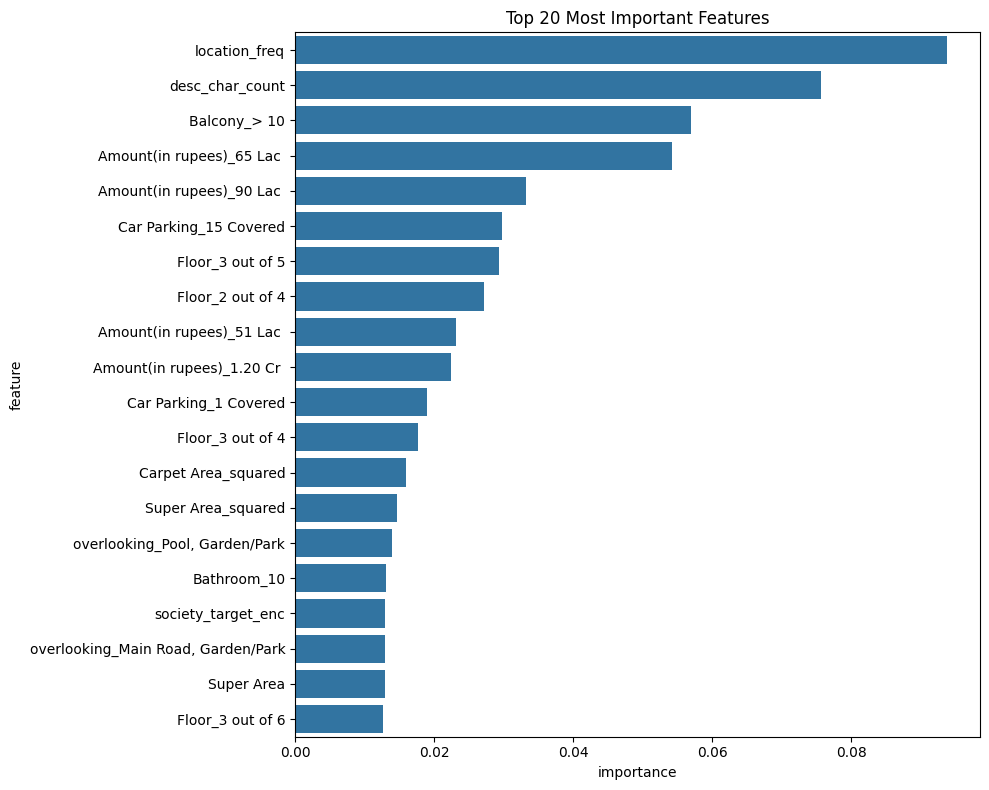

In [ ]:
# Train final model on all encoded training data
X_full_enc, _ = encode_high_cardinality(X, X, y)

# Rebuild feature lists for the encoded data
numerical_features_final = X_full_enc.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_final = X_full_enc.select_dtypes(include=['object']).columns.tolist()

# Fit preprocessor on full encoded data
X_processed = preprocessor.fit_transform(X_full_enc)

final_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_processed, y)

# Get feature names after preprocessing
num_feature_names = numerical_features_final
cat_feature_names = list(
    preprocessor.named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_features_final)
)
feature_names = num_feature_names + cat_feature_names

# Pad feature names if preprocessor added passthrough columns
n_features = X_processed.shape[1]
if len(feature_names) < n_features:
    feature_names += [f'passthrough_{i}' for i in range(n_features - len(feature_names))]

# Plot feature importance
importances = pd.DataFrame({
    'feature': feature_names[:len(final_model.feature_importances_)],
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances, x='importance', y='feature')
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.show()

## Prediction & Deployment


In [ ]:
# Encode test data using the same function (X is used as reference for target encoding)
_, X_test_enc = encode_high_cardinality(X, X_test, y)

# Drop Price column if it exists in test set
if 'Price (in rupees)' in X_test_enc.columns:
    X_test_enc.drop(columns=['Price (in rupees)'], inplace=True)

# Preprocess and predict
X_test_processed = preprocessor.transform(X_test_enc)
predictions_log = final_model.predict(X_test_processed)

# Transform back from log space
predictions = np.expm1(predictions_log)

# Create submission file
submission = pd.DataFrame({
    'Id': test_ids,
    'PredictedPrice': predictions
})

submission.to_csv('submission.csv', index=False)
print("\n✅ Predictions saved to submission.csv")
print(f"Predicted prices range: ₹{predictions.min():,.0f} - ₹{predictions.max():,.0f}")


✅ Predictions saved to submission.csv
Predicted prices range: ₹98 - ₹55,886


## Sanity Checks

In [ ]:
# Check for unrealistic predictions
print("\nSanity Checks:")
print(f"Any negative prices? {(predictions < 0).any()}")
print(f"Any extremely high prices (>₹1Cr)? {(predictions > 10_000_000).any()}")
print(f"Mean predicted price: ₹{predictions.mean():,.0f}")
print(f"Median predicted price: ₹{np.median(predictions):,.0f}")

# Compare to training data
print(f"\nTraining data price range: ₹{np.expm1(y).min():,.0f} - ₹{np.expm1(y).max():,.0f}")


Sanity Checks:
Any negative prices? False
Any extremely high prices (>₹1Cr)? False
Mean predicted price: ₹7,308
Median predicted price: ₹6,024

Training data price range: ₹0 - ₹4,500,000


## Example of the model making predictions

In [ ]:
def predict_house_price(
    carpet_area=500,
    super_area=0,
    bathroom=2,
    balcony=1,
    car_parking=1,
    status='Ready to Move',
    transaction='Resale',
    furnishing='Semi-Furnished',
    facing='East',
    overlooking='Garden/Park',
    ownership='Freehold',
    floor='5 out of 10',
    amount_in_rupees='50 Lac',
    title='2 BHK Ready to Occupy Flat for sale',
    description='A beautiful 2 BHK flat available for sale',
    location='mumbai',
    society='Lodha Palava'
):
    house = pd.DataFrame([{
        'Amount(in rupees)': amount_in_rupees,
        'Carpet Area': float(carpet_area),
        'Super Area': float(super_area),
        'Bathroom': bathroom,
        'Balcony': balcony,
        'Car Parking': car_parking,
        'Status': status,
        'Transaction': transaction,
        'Furnishing': furnishing,
        'facing': facing,
        'overlooking': overlooking,
        'Ownership': ownership,
        'Floor': floor,
        'Title': title,
        'Description': description,
        'location': location,
        'Society': society
    }])

    # Apply same feature engineering as training
    house_engineered = safe_auto_feature_engineering(house, is_test=True, target_col='Price (in rupees)')

    # Ensure all expected columns exist (fill missing ones with 0)
    expected_cols = X_full_enc.columns.tolist()
    for col in expected_cols:
        if col not in house_engineered.columns:
            house_engineered[col] = 0

    # Apply same skew transformations (only on non-null numeric values)
    for feat in ['Carpet Area', 'Super Area', 'Carpet Area_squared', 'Super Area_squared']:
        if feat in house_engineered.columns:
            house_engineered[feat] = house_engineered[feat].apply(
                lambda x: np.log1p(x) if pd.notnull(x) else x
            )

    # Encode high-cardinality features
    _, house_enc = encode_high_cardinality(X, house_engineered, y)

    if 'Price (in rupees)' in house_enc.columns:
        house_enc.drop(columns=['Price (in rupees)'], inplace=True)

    # Preprocess and predict
    house_processed = preprocessor.transform(house_enc)
    pred_log = final_model.predict(house_processed)
    pred_price = np.expm1(pred_log)[0]

    print(f"\n{'='*40}")
    print(f"  PREDICTED PRICE: ₹{pred_price:,.0f}")
    print(f"{'='*40}")
    print(f"  Location:    {location}")
    print(f"  Carpet Area: {carpet_area} sqft")
    print(f"  BHK:         {bathroom}")
    print(f"  Furnishing:  {furnishing}")
    print(f"  Status:      {status}")

    return pred_price

In [ ]:
# Example 1: 2 BHK in Mumbai
predict_house_price(
    carpet_area=800,
    bathroom=2,
    location='mumbai',
    furnishing='Semi-Furnished',
    status='Ready to Move'
)

# Example 2: 3 BHK in Pune, fully furnished
predict_house_price(
    carpet_area=1200,
    bathroom=3,
    balcony=2,
    location='pune',
    furnishing='Furnished',
    society='Lodha Palava',
    status='Ready to Move'
)

# Example 3: Just change what you want, rest uses defaults
predict_house_price(carpet_area=600, location='thane', bathroom=1)


  PREDICTED PRICE: ₹17,736
  Location:    mumbai
  Carpet Area: 800 sqft
  BHK:         2
  Furnishing:  Semi-Furnished
  Status:      Ready to Move

  PREDICTED PRICE: ₹17,221
  Location:    pune
  Carpet Area: 1200 sqft
  BHK:         3
  Furnishing:  Furnished
  Status:      Ready to Move

  PREDICTED PRICE: ₹17,527
  Location:    thane
  Carpet Area: 600 sqft
  BHK:         1
  Furnishing:  Semi-Furnished
  Status:      Ready to Move


np.float32(17526.834)